In [1]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

In [2]:
hotels_tt = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/TravelTime/hotels_traveltime.csv", index_col = 0)
hotelbed = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/hotelbed_hotel.csv", index_col = 0)

In [4]:
corridor = gpd.read_file("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/corridor outline.gpkg")
amsterdam = gpd.read_file("C:/Users/isamu/OneDrive/THESIS/DATA/wijken_amsterdam.geojson")

In [5]:
pt15 = gpd.read_file("C:/Users/isamu/OneDrive/THESIS/DATA/TravelTime/merged_isochrones_pt15.geojson")
pt15 = pt15.rename(columns = {"geometry":"public_transport_15min"})[["place_id", "public_transport_15min"]]

In [6]:
hotelbed["hotelbeds_norm"] = (hotelbed["hotelbeds hotel"]-hotelbed["hotelbeds hotel"].min()
                             )/(hotelbed["hotelbeds hotel"].max()-hotelbed["hotelbeds hotel"].min())

In [7]:
df = hotelbed.merge(hotels_tt, on = "place_id")
df = df.merge(pt15, on = "place_id")

In [21]:
#df.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/hotelbed_traveltime.csv")

In [16]:
df['walking_15min'] = df['walking_15min'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='walking_15min', crs="EPSG:4326")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   place_id                      391 non-null    object  
 1   reviews 2024                  391 non-null    int64   
 2   name_x                        391 non-null    object  
 3   geometry                      391 non-null    object  
 4   Wijkcode                      391 non-null    object  
 5   Wijknaam_x                    391 non-null    object  
 6   Aantal hotelbedden            391 non-null    int64   
 7   reviews 2024_sum              391 non-null    int64   
 8   percentage_reviews_wijk       391 non-null    float64 
 9   hotelbeds hotel               391 non-null    float64 
 10  hotelbeds_norm                391 non-null    float64 
 11  name_y                        391 non-null    object  
 12  main_category                 391 non-null    obje

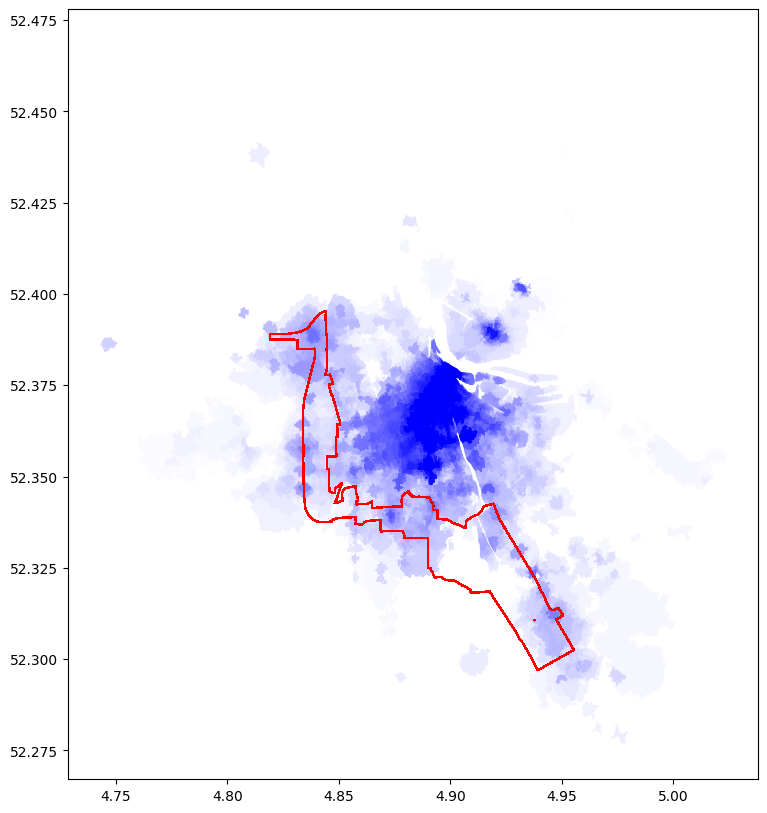

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each polygon individually so we can set alpha dynamically
for _, row in gdf.iterrows():
    gpd.GeoSeries([row['public_transport_15min']]).plot(
        ax=ax,
        color='blue',   # Or any color you want
        alpha=row['hotelbeds_norm']*0.1  # This controls the transparency
    )

    corridor['geometry'].plot(
    ax=ax,
    color='none',
    edgecolor='red',
    linewidth=1)
    
plt.show()

In [25]:
#hotelbed.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/hotelbed_normalized.csv")